In [1]:
import pandas as pd
import numpy as np
from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\function_dataset_cleaned_v2.csv')

In [3]:
X = df.drop(columns=['label'])
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

## 特徵工程

In [5]:
# 先將原本10個欄位拿去訓練模型
best_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\best_model_v2.joblib')
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("原始特徵:")
print(f"準確度: {accuracy:.3f}")

原始特徵:
準確度: 0.743


In [7]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, y_pred)}")

混淆矩陣:
[[83  1  0  0  1  1  0 14]
 [ 0 72  8  0  0 17  0  3]
 [ 1  6 50  7 11 14  6  5]
 [ 0  0 11 72 12  1  3  1]
 [ 0  0  2  6 74  0 18  0]
 [ 2  3  9  6  1 76  3  0]
 [ 0  0  5  0 16  1 78  0]
 [ 8  0  0  0  1  0  2 89]]


In [8]:
print(f"分類報告:\n{classification_report(y_test, y_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.88      0.83      0.86       100
       cubic       0.88      0.72      0.79       100
 exponential       0.59      0.50      0.54       100
      linear       0.79      0.72      0.75       100
 logarithmic       0.64      0.74      0.69       100
   quadratic       0.69      0.76      0.72       100
  reciprocal       0.71      0.78      0.74       100
        sine       0.79      0.89      0.84       100

    accuracy                           0.74       800
   macro avg       0.75      0.74      0.74       800
weighted avg       0.75      0.74      0.74       800



In [9]:
# 將原始資料標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 訓練集

In [10]:
train_first_diff = np.diff(X_train.values, axis=1)          # 一階差分
train_second_diff = np.diff(X_train.values, n=2, axis=1)    # 二階差分
train_amplitude = X_train.max(axis=1) - X_train.min(axis=1) # 變化總幅度

train_x = np.linspace(-2, 2, X_train.shape[1]).reshape(-1, 1)
train_slopes = []                                           # 每一筆函數的整體迴歸斜率
for row in X_train.values:
    train_model = LinearRegression()
    train_model.fit(train_x, row)
    train_slopes.append(train_model.coef_[0])
train_slopes = np.array(train_slopes)

In [11]:
print(f"訓練數據的形狀: {X_train_scaled.shape}")

訓練數據的形狀: (3200, 10)


In [12]:
print(f"原始最大值:\n{X_train.max(axis=0)}\n")              # 最大值
print(f"標準化後的最大值:\n{X_train_scaled.max(axis=0)}\n")

原始最大值:
y_0    28.540467
y_1    17.886468
y_2    11.016238
y_3     6.078918
y_4     5.366088
y_5     5.392449
y_6     6.873149
y_7     9.698118
y_8    17.364683
y_9    32.127451
dtype: float64

標準化後的最大值:
[5.53849333 5.4940884  4.72879735 3.05950172 2.83850154 2.84286062
 3.41241893 4.0211441  5.1566124  6.07135653]



In [13]:
print(f"原始最小值:\n{X_train.min(axis=0)}\n")              # 最小值
print(f"標準化後的最小值:\n{X_train_scaled.min(axis=0)}\n")

原始最小值:
y_0   -28.329839
y_1   -15.804016
y_2    -8.942700
y_3    -6.350795
y_4    -5.792095
y_5    -5.858799
y_6    -6.766447
y_7    -9.695319
y_8   -17.140795
y_9   -31.286013
dtype: float64

標準化後的最小值:
[-5.47443761 -4.83798889 -3.82891201 -3.19062053 -3.06452105 -3.10569648
 -3.3862468  -4.04693207 -5.12055008 -5.93641843]



In [14]:
print(f"原始平均值:\n{X_train.mean(axis=0)}\n")

原始平均值:
y_0   -0.060077
y_1   -0.028467
y_2   -0.012621
y_3   -0.005560
y_4    0.000613
y_5    0.015392
y_6    0.027097
y_7    0.032393
y_8    0.051404
y_9    0.064412
dtype: float64



In [15]:
print(f"原始標準差:\n{X_train.std(axis=0)}\n")

原始標準差:
y_0    5.164764
y_1    3.261275
y_2    2.332640
y_3    1.989026
y_4    1.890545
y_5    1.891720
y_6    2.006530
y_7    2.404101
y_8    3.358015
y_9    5.281859
dtype: float64



In [16]:
print(f"迴歸斜率:(取前5筆資料)\n{train_slopes[:5]}\n")

迴歸斜率:(取前5筆資料)
[ 2.0975006   0.03003401  2.45221774 -1.87345208 -1.50934186]



In [17]:
print("經過一階差分處理後的結果:(取前5筆資料)")
train_first_diff_mean = train_first_diff.mean(axis=1)
train_first_diff_std = train_first_diff.std(axis=1)
print(f"平均值:\n{train_first_diff_mean[:5]}")
print(f"標準差:\n{train_first_diff_std[:5]}\n")

經過一階差分處理後的結果:(取前5筆資料)
平均值:
[ 1.30438289  0.20605948  1.30854912 -0.83468341 -0.66779417]
標準差:
[1.48237856 1.10103545 1.33542316 0.39520244 1.58126771]



In [18]:
print("經過二階差分處理後的結果:(取前5筆資料)")
train_second_diff_mean = train_second_diff.mean(axis=1)
train_second_diff_std = train_second_diff.std(axis=1)
print(f"平均值:\n{train_second_diff_mean[:5]}")
print(f"標準差:\n{train_second_diff_std[:5]}\n")

經過二階差分處理後的結果:(取前5筆資料)
平均值:
[-0.35835918  0.15542188  0.50802223 -0.1209054   0.54574731]
標準差:
[0.97065618 1.0181901  0.73964603 0.20013988 0.72200199]



In [19]:
print(f"變化幅度:(取前5筆資料)\n{train_amplitude[:5]}\n")

變化幅度:(取前5筆資料)
1025    11.739446
3173     3.527282
1817    11.776942
959      7.512151
732      9.702262
dtype: float64



In [20]:
# 建立 X_train 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
train_math_features = pd.DataFrame({'slope': train_slopes,
                                    'amplitude': train_amplitude,
                                    'first_diff_mean': train_first_diff_mean,
                                    'first_diff_std': train_first_diff_std,
                                    'second_diff_mean': train_second_diff_mean,
                                    'second_diff_std': train_second_diff_std})

In [21]:
print(f"X_train數學特徵前5筆:\n{train_math_features.head()}")

X_train數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
1025  2.097501  11.739446         1.304383        1.482379         -0.358359   
3173  0.030034   3.527282         0.206059        1.101035          0.155422   
1817  2.452218  11.776942         1.308549        1.335423          0.508022   
959  -1.873452   7.512151        -0.834683        0.395202         -0.120905   
732  -1.509342   9.702262        -0.667794        1.581268          0.545747   

      second_diff_std  
1025         0.970656  
3173         1.018190  
1817         0.739646  
959          0.200140  
732          0.722002  


In [22]:
# 加入原始特徵
X_train_math = pd.concat([X_train.reset_index(drop=True),
                          train_math_features.reset_index(drop=True)], axis=1)

In [23]:
print(f"X_train_math 形狀為: {X_train_math.shape}")

X_train_math 形狀為: (3200, 16)


### 測試集

In [24]:
test_first_diff = np.diff(X_test.values, axis=1)            # 一階差分
test_second_diff = np.diff(X_test.values, n=2, axis=1)      # 二階差分
test_amplitude = X_test.max(axis=1) - X_test.min(axis=1)    # 變化總幅度

test_x = np.linspace(-2, 2, X_test.shape[1]).reshape(-1, 1)
test_slopes = []                                            # 每一筆函數的整體迴歸斜率
for row in X_test.values:
    test_model = LinearRegression()
    test_model.fit(test_x, row)
    test_slopes.append(test_model.coef_[0])
test_slopes = np.array(test_slopes)

# 一階差分統計
test_first_diff_mean = test_first_diff.mean(axis=1)
test_first_diff_std = test_first_diff.std(axis=1)
# 二階差分統計
test_second_diff_mean = test_second_diff.mean(axis=1)
test_second_diff_std = test_second_diff.std(axis=1)

In [25]:
# 建立 X_test 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
test_math_features = pd.DataFrame({'slope': test_slopes,
                                   'amplitude': test_amplitude,
                                   'first_diff_mean': test_first_diff_mean,
                                   'first_diff_std': test_first_diff_std,
                                   'second_diff_mean': test_second_diff_mean,
                                   'second_diff_std': test_second_diff_std})

In [26]:
print(f"X_test數學特徵前5筆:\n{test_math_features.head()}")

X_test數學特徵前5筆:
         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
669   1.223503   6.549634         0.562075        0.932414          0.322638   
622   1.327131   9.180428         0.606497        1.627726          0.618395   
2417  0.156586   0.636597         0.070733        0.021484         -0.006559   
3925  0.215916   0.978130         0.108681        0.088834         -0.033854   
2662 -0.047708   1.441104        -0.102946        0.724876          0.043515   

      second_diff_std  
669          0.511516  
622          0.504363  
2417         0.023485  
3925         0.082348  
2662         1.066362  


In [27]:
# 加入原始特徵
X_test_math = pd.concat([X_test.reset_index(drop=True),
                         test_math_features.reset_index(drop=True)], axis=1)

In [28]:
print(f"X_test_math 形狀為: {X_test_math.shape}")

X_test_math 形狀為: (800, 16)


### 把訓練集跟測試集結合成一個大表格

In [29]:
X_math_merged = pd.concat([X_train_math.reset_index(drop=True),
                           X_test_math.reset_index(drop=True)], axis=0)

In [30]:
print(f"把訓練數據跟測試數據合併之後, 形狀為: {X_math_merged.shape}\n")

把訓練數據跟測試數據合併之後, 形狀為: (4000, 16)



### 將合併後的表格儲存成新的檔案

In [31]:
y_merged = pd.concat([y_train.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=0)

In [32]:
math_merged = pd.concat([y_merged, X_math_merged], axis=1)

In [33]:
math_merged.to_csv(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\function_dataset_merged_v2.csv', index=False)

### 標準化

In [34]:
scaler_after = StandardScaler()
X_train_math_scaled = scaler_after.fit_transform(X_train_math)
X_test_math_scaled = scaler_after.transform(X_test_math)

In [35]:
print("標準化之後:")
print(f"平均值:\n{X_train_math_scaled.mean(axis=0)}")
print(f"標準差:\n{X_train_math_scaled.std(axis=0)}")

標準化之後:
平均值:
[-3.33066907e-18  1.99840144e-17  2.83106871e-17 -1.02695630e-17
  2.55351296e-17  1.11022302e-18  3.33066907e-17  1.11022302e-17
 -2.22044605e-18  1.77635684e-17 -2.22044605e-18  4.44089210e-18
 -4.44089210e-18  1.22124533e-16  1.11022302e-17  4.44089210e-18]
標準差:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 將結合後的數據再訓練模型一次

In [36]:
best_model_math = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\best_model_v2.joblib')
best_model_math.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_pred_math = best_model_math.predict(X_test_math)
math_accuracy = accuracy_score(y_test.reset_index(drop=True), y_pred_math)

In [38]:
print("新增一些數學特徵之後:")
print(f"準確度: {math_accuracy:.3f}")

新增一些數學特徵之後:
準確度: 0.825


In [39]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), y_pred_math)}\n")

混淆矩陣:
[[85  0  1  0  1  0  1 12]
 [ 0 76  5  0  0 16  0  3]
 [ 1  5 54 13  6 17  4  0]
 [ 0  0  7 85  6  2  0  0]
 [ 0  0  1  3 94  0  2  0]
 [ 1  6  3  6  0 84  0  0]
 [ 0  0  5  0  1  0 94  0]
 [ 9  0  0  0  0  0  3 88]]



In [40]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), y_pred_math)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.89      0.85      0.87       100
       cubic       0.87      0.76      0.81       100
 exponential       0.71      0.54      0.61       100
      linear       0.79      0.85      0.82       100
 logarithmic       0.87      0.94      0.90       100
   quadratic       0.71      0.84      0.77       100
  reciprocal       0.90      0.94      0.92       100
        sine       0.85      0.88      0.87       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



### 比較結果

In [41]:
# 比較結果
improvement = math_accuracy - accuracy
print("----實驗結果----")
print(f"原始特徵準確度: {accuracy:.4f}")
print(f"數學特徵準確度: {math_accuracy:.4f}")
print(f"比原本特徵進步了: {improvement:+.4f}")
print("結論:", end=" ")
if improvement > 0:
    print("加入數學特徵後, 準確度提升。")
elif improvement < 0:
    print("加入數學特徵後, 準確度下降。")
else:
    print("加入數學特徵後, 準確度沒有改變。")

----實驗結果----
原始特徵準確度: 0.7425
數學特徵準確度: 0.8250
比原本特徵進步了: +0.0825
結論: 加入數學特徵後, 準確度提升。


## 特徵重要性

In [42]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [43]:
feature_importance = best_model_math.feature_importances_
feature_names = X_train_math.columns
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance})

In [44]:
# 由高到低排序
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [45]:
print(importance_df.head(10).to_string(index=False, formatters={'Importance': '{:.3f}'.format}))

         Feature Importance
  first_diff_std      0.158
       amplitude      0.143
 second_diff_std      0.119
second_diff_mean      0.106
 first_diff_mean      0.098
           slope      0.085
             y_9      0.043
             y_0      0.039
             y_8      0.030
             y_7      0.027


In [46]:
importance_df.to_html(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\feature_importance_v2.html')

In [47]:
math_feature_names = ['slope', 'amplitude', 'first_diff_mean', 'first_diff_std',
                      'second_diff_mean', 'second_diff_std']
math_importance_df = importance_df[importance_df['Feature'].isin(math_feature_names)].copy()

In [48]:
print(math_importance_df.to_string(index=False, formatters={'Importance': '{:.3f}'.format}))

         Feature Importance
  first_diff_std      0.158
       amplitude      0.143
 second_diff_std      0.119
second_diff_mean      0.106
 first_diff_mean      0.098
           slope      0.085


In [49]:
math_total_importance = (math_importance_df['Importance'].sum())    # 計算數學特徵的重要性總和
raw_total_importance = (importance_df[~importance_df['Feature'].isin(math_feature_names)]['Importance'].sum())
print("特徵群組重要性總和:")
print(f"原始 y: {raw_total_importance:.3f}")
print(f"6 個數學特徵: {math_total_importance:.3f}")

特徵群組重要性總和:
原始 y: 0.291
6 個數學特徵: 0.709


In [50]:
most_important_math = (math_importance_df.iloc[0])      # 找出最重要的數學特徵
print(f"最重要的數學特徵: {most_important_math['Feature']} ({most_important_math['Importance']:.4f})")

最重要的數學特徵: first_diff_std (0.1581)


In [51]:
# 畫出前 10 名 Feature Importance
top_n = 10
top_features = importance_df.head(top_n).copy()
top_features = top_features.sort_values(by='Importance', ascending=True)    # 為了畫圖讓最重要的在最上面

C:\Users\user\AppData\Local\Temp\ipykernel_504\974383017.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


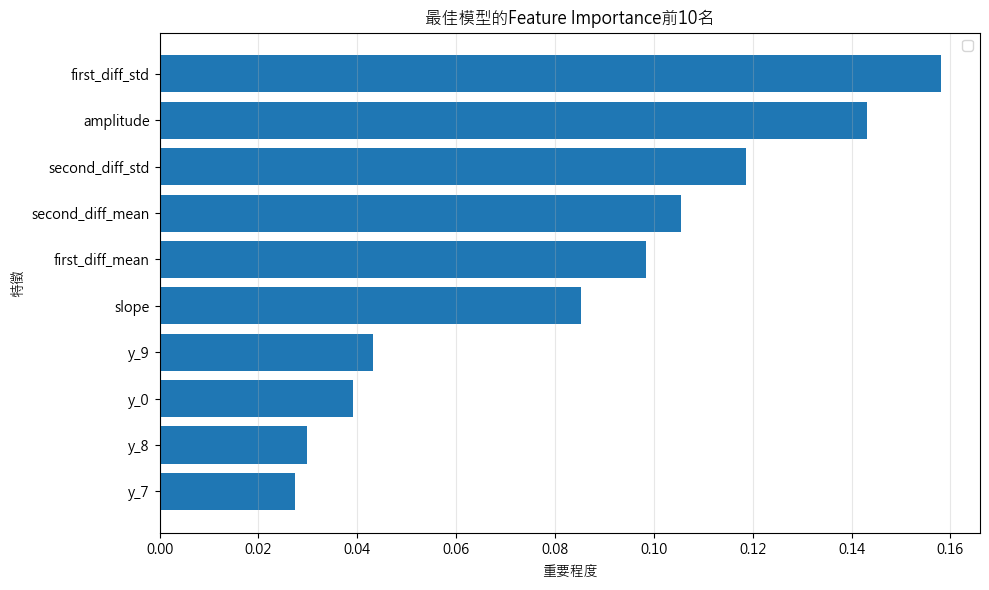

In [52]:
# 繪製圖表
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("重要程度")
plt.ylabel("特徵")
plt.title("最佳模型的Feature Importance前10名")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(r'D:\Python\我的AI作品集\專案1_數學函數辨識\data\v2\feature_importance_top10_v2.png')
plt.show()

## 模型調參

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

In [54]:
# 調參前模型
baseline_model = load(r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\best_model_v2.joblib')
baseline_model.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
baseline_pred = baseline_model.predict(X_test_math)
baseline_accuracy = accuracy_score(y_test.reset_index(drop=True), baseline_pred)
print("模型調參前")
print(f"準確度: {baseline_accuracy:.3f}\n")

模型調參前
準確度: 0.825



In [56]:
# 設定 GridSearchCV
rf_model = RandomForestClassifier(random_state=10)
param_grid = {'n_estimators': [100, 150, 200],
              'max_depth': [None, 10, 20],
              'min_samples_split': [2, 3, 5],
              'min_samples_leaf': [1]}

In [57]:
# 開始 GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_math, y_train.reset_index(drop=True))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [58]:
print(f"最佳參數: {grid_search.best_params_}")
print(f"最佳CV準確度: {grid_search.best_score_:.4f}\n")

最佳參數: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
最佳CV準確度: 0.7953



In [59]:
# 使用最佳模型預測
best_model = grid_search.best_estimator_

In [60]:
train_pred = best_model.predict(X_train_math)
test_pred = best_model.predict(X_test_math)
train_accuracy = accuracy_score(y_train.reset_index(drop=True), train_pred)
test_accuracy = accuracy_score(y_test.reset_index(drop=True), test_pred)
print("模型調參後")
print(f"訓練數據準確度: {train_accuracy:.3f}")
print(f"測試數據準確度: {test_accuracy:.3f}")

模型調參後
訓練數據準確度: 1.000
測試數據準確度: 0.825


In [61]:
# 比較調參前後
print("----實驗結果----")
print(f"調參前準確度: {baseline_accuracy:.4f}")
print(f"調參後準確度: {test_accuracy:.4f}")
improvement = test_accuracy - baseline_accuracy
print(f"改善幅度: {improvement:+.4f}")
print("結論:", end=" ")
if improvement > 0:
    print("模型調參後，測試準確度提升。")
elif improvement < 0:
    print("模型調參後，測試準確度下降。")
else:
    print("測試準確度沒有改變。\n")

----實驗結果----
調參前準確度: 0.8250
調參後準確度: 0.8250
改善幅度: +0.0000
結論: 測試準確度沒有改變。



In [62]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), test_pred)}")

混淆矩陣:
[[85  0  1  0  1  0  1 12]
 [ 0 76  5  0  0 16  0  3]
 [ 1  5 54 13  6 17  4  0]
 [ 0  0  7 85  6  2  0  0]
 [ 0  0  1  3 94  0  2  0]
 [ 1  6  3  6  0 84  0  0]
 [ 0  0  5  0  1  0 94  0]
 [ 9  0  0  0  0  0  3 88]]


In [63]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), test_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.89      0.85      0.87       100
       cubic       0.87      0.76      0.81       100
 exponential       0.71      0.54      0.61       100
      linear       0.79      0.85      0.82       100
 logarithmic       0.87      0.94      0.90       100
   quadratic       0.71      0.84      0.77       100
  reciprocal       0.90      0.94      0.92       100
        sine       0.85      0.88      0.87       100

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



In [64]:
# 儲存最佳模型
joblib.dump(best_model, r'D:\Python\我的AI作品集\專案1_數學函數辨識\models\v2\best_model_tuned_v2.joblib')

['D:\\Python\\我的AI作品集\\專案1_數學函數辨識\\models\\v2\\best_model_tuned_v2.joblib']

In [65]:
print("V2 調參後最佳模型已儲存!")

V2 調參後最佳模型已儲存!
